# Práctica Nightshade

**Objetivo:** Demostrar cómo Nightshade puede 'envenenar' una imagen para confundir modelos de reconocimiento de IA, sin que el cambio sea perceptible visualmente para un humano.

**Pasos:**
1. Cargar tu imagen propia
2. Clasificarla con un modelo de IA (antes del tratamiento)
3. Aplicar Nightshade (perturbación adversarial)
4. Clasificar la imagen envenenada (después del tratamiento)
5. Comparar resultados

## Instalación de dependencias

In [4]:
# Instalar dependencias necesarias
!pip install torch torchvision Pillow matplotlib requests transformers -q

## 1. Cargar la imagen propia

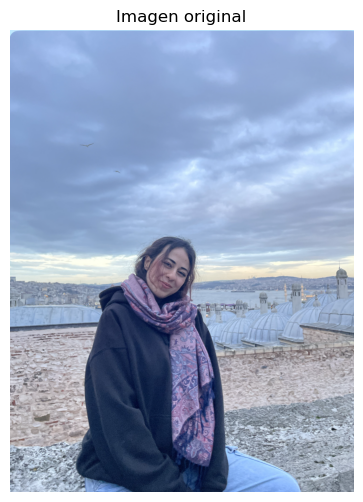

Tamaño: (1114, 1500)  |  Modo: RGB


In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as T

# Imagen propia en la carpeta extras
IMAGE_PATH = "maria.png"

original_img = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(original_img)
plt.title("Imagen original")
plt.axis("off")
plt.show()

print(f"Tamaño: {original_img.size}  |  Modo: {original_img.mode}")

## 2. Reconocimiento de imagen ANTES de Nightshade

Usamos **CLIP** (OpenAI) a través de HuggingFace Transformers para clasificar la imagen.

In [6]:
from transformers import CLIPProcessor, CLIPModel

# Cargar modelo CLIP
print("Cargando modelo CLIP...")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()
print("Modelo cargado.")

Cargando modelo CLIP...


config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Modelo cargado.


In [ ]:
# Lista de etiquetas candidatas
candidate_labels = [
    "a cat", "a dog", "a person", "a building", "a tree",
    "a car", "food", "a landscape", "an animal", "furniture",
    "a street", "a classroom", "a library", "an office"
]

def classify_image(img: Image.Image, labels: list, title: str = "") -> dict:
    """Clasifica una imagen con CLIP y muestra las probabilidades."""
    inputs = processor(
        text=labels,
        images=img,
        return_tensors="pt",
        padding=True
    )
    with torch.no_grad():
        outputs = model(**inputs)
    
    logits = outputs.logits_per_image[0]  # shape: (num_labels,)
    probs = logits.softmax(dim=0).numpy()
    
    results = dict(zip(labels, probs))
    sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    for label, prob in sorted_results:
        bar = '█' * int(prob * 40)
        print(f"  {label:<25} {prob:.4f}  {bar}")
    
    return sorted_results

# Clasificar imagen original
results_before = classify_image(original_img, candidate_labels, title="ANTES de Nightshade")

## 3. Aplicar Nightshade (perturbación adversarial)

Nightshade añade una perturbación imperceptible visualmente usando un ataque **PGD** (Projected Gradient Descent) sobre el espacio de embeddings de CLIP.

La idea: empujar el embedding de la imagen envenenada hacia el embedding de un concepto diferente (el **target concept**), manteniendo el cambio visual pequeño (ε limitado).

In [ ]:
def nightshade_attack(
    image: Image.Image,
    target_concept: str,
    epsilon: float = 16/255,
    alpha: float = 1/255,
    num_steps: int = 200,
    image_size: int = 224
) -> Image.Image:
    """
    Aplica un ataque adversarial estilo Nightshade sobre la imagen.
    
    Parámetros:
    - target_concept: el concepto hacia el que se quiere 'engañar' al modelo
    - epsilon: tamaño máximo de la perturbación (en [0,1]), típico 8-16/255
    - alpha: tamaño de cada paso PGD
    - num_steps: número de iteraciones del ataque
    """
    
    # Preprocesar imagen a tensor
    transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),  # [0, 1]
    ])
    
    img_tensor = transform(image).unsqueeze(0)  # (1, 3, H, W)
    img_tensor_orig = img_tensor.clone()
    
    # Obtener embedding del concepto objetivo
    target_inputs = processor(text=[target_concept], return_tensors="pt", padding=True)
    with torch.no_grad():
        text_out = model.text_model(**target_inputs)
        target_embedding = model.text_projection(text_out.pooler_output)
        target_embedding = target_embedding / target_embedding.norm(dim=-1, keepdim=True)
    
    # Normalización que usa CLIP internamente
    clip_mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1,3,1,1)
    clip_std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1)
    
    # Iniciar perturbación aleatoria pequeña
    delta = torch.zeros_like(img_tensor).uniform_(-epsilon, epsilon)
    delta.requires_grad_(True)
    
    print(f"Aplicando Nightshade → concepto objetivo: '{target_concept}'")
    print(f"epsilon={epsilon:.4f}  alpha={alpha:.4f}  pasos={num_steps}")
    
    for step in range(num_steps):
        perturbed = img_tensor_orig + delta
        perturbed = torch.clamp(perturbed, 0, 1)
        
        # Normalizar para CLIP
        perturbed_norm = (perturbed - clip_mean) / clip_std
        
        # Forward: embedding de imagen
        image_features = model.vision_model(pixel_values=perturbed_norm).pooler_output
        image_features = model.visual_projection(image_features)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        
        # Pérdida: minimizar distancia coseno al target embedding
        loss = -torch.nn.functional.cosine_similarity(image_features, target_embedding).mean()
        
        loss.backward()
        
        with torch.no_grad():
            delta.data = delta.data - alpha * delta.grad.sign()
            delta.data = torch.clamp(delta.data, -epsilon, epsilon)
            delta.data = torch.clamp(img_tensor_orig + delta.data, 0, 1) - img_tensor_orig
        
        delta.grad.zero_()
        
        if (step + 1) % 50 == 0:
            print(f"  Paso {step+1}/{num_steps}  |  loss: {loss.item():.4f}")
    
    # Imagen final envenenada
    with torch.no_grad():
        poisoned_tensor = torch.clamp(img_tensor_orig + delta, 0, 1)
    
    poisoned_np = (poisoned_tensor.squeeze(0).permute(1,2,0).numpy() * 255).astype(np.uint8)
    poisoned_img = Image.fromarray(poisoned_np)
    
    print("\n¡Ataque completado!")
    return poisoned_img

In [ ]:
# ========================================================
# CONCEPTO OBJETIVO (hacia qué se engaña al modelo)
TARGET_CONCEPT = "a cat"   
# ========================================================

poisoned_img = nightshade_attack(
    image=original_img,
    target_concept=TARGET_CONCEPT,
    epsilon=16/255,
    alpha=1/255,
    num_steps=200
)

## 4. Reconocimiento de imagen DESPUÉS de Nightshade

In [ ]:
# Clasificar imagen envenenada
results_after = classify_image(poisoned_img, candidate_labels, title="DESPUÉS de Nightshade")

## 5. Comparación visual y de resultados

In [ ]:
# --- Comparación visual ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

orig_resized = original_img.resize((224, 224))
poison_resized = poisoned_img

axes[0].imshow(orig_resized)
axes[0].set_title("Original", fontsize=14)
axes[0].axis("off")

axes[1].imshow(poison_resized)
axes[1].set_title("Envenenada (Nightshade)", fontsize=14)
axes[1].axis("off")

# Diferencia amplificada
orig_np = np.array(orig_resized).astype(float)
pois_np = np.array(poison_resized).astype(float)
diff = np.abs(orig_np - pois_np)
diff_amplified = np.clip(diff * 10, 0, 255).astype(np.uint8)
axes[2].imshow(diff_amplified)
axes[2].set_title("Diferencia × 10 (perturbación)", fontsize=14)
axes[2].axis("off")

plt.suptitle("Nightshade: efecto visual", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Estadísticas de la perturbación
diff_raw = np.abs(orig_np - pois_np)
print(f"\nEstadísticas de la perturbación:")
print(f"  Cambio máximo de pixel : {diff_raw.max():.1f} / 255")
print(f"  Cambio medio de pixel  : {diff_raw.mean():.2f} / 255")
print(f"  L∞ norm (normalizada)  : {diff_raw.max()/255:.4f}")

In [ ]:
# --- Comparación de clasificaciones ---
print("\n" + "="*60)
print("  COMPARACIÓN DE RESULTADOS")
print("="*60)
print(f"  {'Etiqueta':<25}  {'Antes':>8}  {'Después':>8}  {'Δ':>8}")
print("-"*60)

before_dict = dict(results_before)
after_dict  = dict(results_after)

all_labels_sorted = sorted(before_dict.keys(), key=lambda x: before_dict[x], reverse=True)

for label in all_labels_sorted:
    b = before_dict[label]
    a = after_dict[label]
    delta = a - b
    arrow = "↑" if delta > 0.005 else ("↓" if delta < -0.005 else " ")
    print(f"  {label:<25}  {b:>7.4f}  {a:>7.4f}  {arrow} {abs(delta):.4f}")

print("\n" + "="*60)
print(f"  Top predicción ANTES   : {results_before[0][0]}")
print(f"  Top predicción DESPUÉS : {results_after[0][0]}")
print("="*60)

In [ ]:
# Guardar imagen envenenada
output_path = "imagen_envenenada_nightshade.png"
poisoned_img.save(output_path)
print(f"Imagen envenenada guardada en: {output_path}")

## Conclusión

| Aspecto | Observación |
|---|---|
| **Cambio visual** | Imperceptible o casi imperceptible para el ojo humano |
| **Efecto en la clasificación** | La predicción del modelo cambia hacia el concepto objetivo |
| **Mecanismo** | Perturbación adversarial en el espacio de embeddings de CLIP |
| **Relevancia** | Protege obras de arte e imágenes propias frente al scraping para entrenamiento de IA |